# Spectral fitting example (AGN)


This notebook fits the spectrum of a simulated AGN observation with COSI using the same 3ML workflow as the Crab spectral fitting tutorial.

The binned mock data already include NGC 4151 plus background. The fit uses the mock histogram as the observed data and uses `mock - NGC4151` as the fitted background template, with NGC 4151 modeled as a cutoff-power-law thermal component plus an optional simple-power-law non-thermal tail.


In [1]:
from cosipy import BinnedData
from cosipy.spacecraftfile import SpacecraftHistory
from cosipy.event_selection import GoodTimeInterval
from cosipy.response.FullDetectorResponse import FullDetectorResponse
from cosipy.util import fetch_wasabi_file

from cosipy.statistics import PoissonLikelihood
from cosipy.background_estimation import FreeNormBinnedBackground
from cosipy.interfaces import ThreeMLPluginInterface
from cosipy.response import BinnedThreeMLModelFolding, BinnedInstrumentResponse, BinnedThreeMLPointSourceResponse
from cosipy.data_io import EmCDSBinnedData

from histpy import Histogram

import sys

import astropy.units as u
from astropy.coordinates import SkyCoord

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from threeML import PointSource, Model, JointLikelihood, DataList
from astromodels import Parameter, Cutoff_powerlaw, Powerlaw, Line

from pathlib import Path

%matplotlib inline


22:19:47 WARNING   The naima package is not available. Models that depend on it will not be         ]8;id=764670;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=110234;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py#43\43]8;;\
                  available                                                                                        

         WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=938953;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=306004;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py#65\65]8;;\
                  will not be available.                                                                           

         WARNING   The ebltable package is not available. Models that depend on it will not be     ]8;id=166442;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/absorption.py\absorption.py]8;;\:]8;id=668435;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/absorption.py#33\33]8;;\
                  available                                                                                        

22:19:47 INFO      Starting 3ML!                                                                     ]8;id=554042;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=981811;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#44\44]8;;\

         WARNING   WARNINGs here are NOT errors                                                      ]8;id=398422;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=990875;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#45\45]8;;\

...

         WARNING   Could not import plugin FermiLATLike.py. Do you have the relative instrument     ]8;id=758831;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=766812;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#126\126]8;;\
                  software installed and configured?                                                               

         WARNING   No fermitools installed                                              ]8;id=185393;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=471107;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#44\44]8;;\

         WARNING   Env. variable OMP_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=157524;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=356054;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable MKL_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=647313;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=931971;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable NUMEXPR_NUM_THREADS is not set. Please set it to 1 for optimal     ]8;id=333818;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=254769;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

## Download and read in binned data


Define the paths to the mock data, original NGC 4151 data, detector response, orientation file, and yaml configuration. The mock data are expected to be binned before running this notebook.


In [5]:
analysis_dir = Path.cwd()
if not (analysis_dir / "agn.yaml").exists():
    repo_notebook_dir = Path("/Users/parshadkp/Software/cosipy/docs/tutorials/spectral_fits/continuum_fit/AGN")
    if repo_notebook_dir.exists():
        analysis_dir = repo_notebook_dir

# binned_mock_data_file = Path("/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Software_Files/DC4_Files/Mock_Data/mock_with_updated_NGC4151_FluxNTH_0p35_time_cut.hdf5")
# NGC4151_file = Path("/Users/parshadkp/Software/COSI_Data/DC4_Files/NGC_4151_ec200_0p35_DC3_COSI_cpl_pl_time_cut_in_fov.hdf5")

binned_mock_data_file = Path("/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Software_Files/DC4_Files/Mock_Data/mock_with_updated_NGC4151_FluxNTH_0p15_time_cut.hdf5")
NGC4151_file = Path("/Users/parshadkp/Software/COSI_Data/DC4_Files/NGC_4151_ec200_DC4_COSI_cpl_pl_fluxNTH_0p15_time_cut_in_fov.hdf5")

# binned_mock_data_file = Path("/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Software_Files/DC4_Files/Mock_Data/dc4_mock_dataset_3months_unbinned_data_filtered_with_SAAcut_time_ordered_ngc4151_in_fov_binned.hdf5")
# NGC4151_file = Path("/Users/parshadkp/Software/COSI_Data/DC4_Files/NGC_4151__3months_unbinned_data_filtered_with_SAAcut_ngc4151_in_fov_binned.hdf5")

orientation_path = "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Software_Files/DC4_Files/DC4_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.ori"
response_path = "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Software_Files/DC4_Files/ResponseContinuum.o3.e100_10000.b10log.s10396905069491.m2284.filtered.nonsparse.binnedimaging.imagingresponse.h5"
agn_config = analysis_dir / "agn.yaml"

exposure_multiplier = 1
reference_flux_multiplier = exposure_multiplier
count_exposure_multiplier = exposure_multiplier

# Toggle whether the response uses the NGC 4151 FOV-cut spacecraft history.
use_time_cut_orientation = True
include_nonthermal_tail = True
tail_ratio_at_200keV = 0.15
max_offaxis = 60 * u.deg
earth_occ = True

source_label = "NGC 4151"
source_l = 155.07 * u.deg
source_b = 75.06 * u.deg
source_coord = SkyCoord(l=source_l, b=source_b, frame="galactic")

Sigma (Mock Data): 12.998
Sigma (Single Source): 17.577


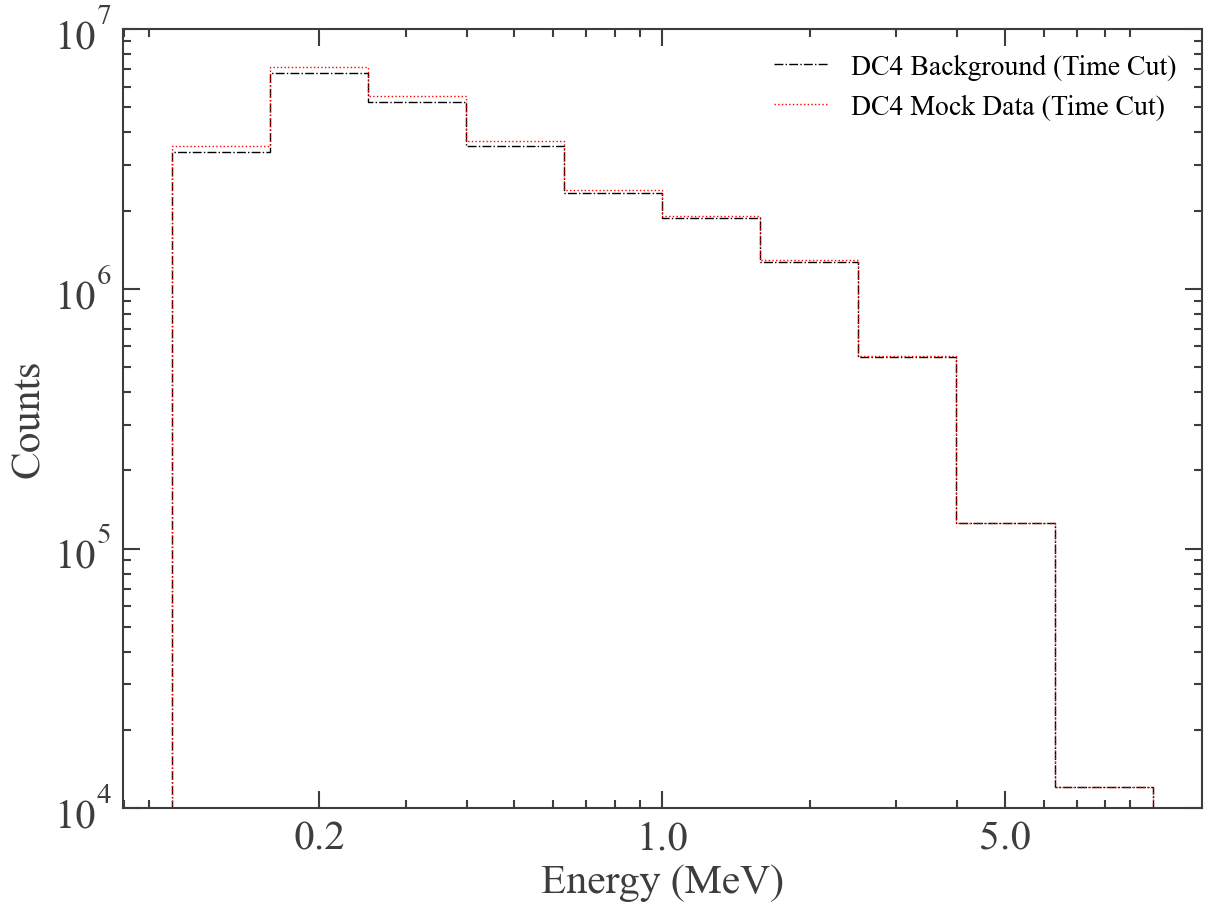

: 

In [ ]:
total_mock_data = Path("/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Software_Files/DC4_Files/Mock_Data/mock_with_updated_NGC4151_FluxNTH_0p15_time_cut.hdf5")
background_DC4 = Path("/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Software_Files/DC4_Files/Total_DC4_BG_3months_unbinned_data_filtered_with_SAAcut_withSAAbck_ngc4151_in_fov_binned.hdf5")
background_DC4_old = Path("/Users/parshadkp/Software/COSI_Data/DC4_Files/Total_DC4_BG_3months_binned_data_filtered_with_SAAcut_withSAAbck_NGC4151_TimeCut.hdf5")
NGC_4151_old = Path("/Users/parshadkp/Software/COSI_Data/AGN_Data/GammaRay/Paper_Models/NGC_4151_ec200_DC3_COSI_cpl_pl.hdf5")

FONT_SIZE = 30
plt.rcParams["agg.path.chunksize"] = 10000
plt.rcParams.update({"font.size": FONT_SIZE})
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["axes.linewidth"] = 1.5
plt.rcParams.update({
    "font.weight": "550",
    "axes.titleweight": "550",
    "axes.labelweight": "550",
})

total_mock_data = Histogram.open(total_mock_data)
background_DC4 = Histogram.open(background_DC4)
background_DC4_old = Histogram.open(background_DC4_old)
NGC_4151_hist_comp = Histogram.open(NGC4151_file)
NGC_4151_hist_old = Histogram.open(NGC_4151_old)

def projection_counts(hist, axis_name):
    return hist.project(axis_name).to_dense(copy=False).contents


def style_axis(ax):
    ax.xaxis.set_tick_params(which="major", size=12, width=1.5, direction="in", top=True, pad=8, labelsize=FONT_SIZE)
    ax.xaxis.set_tick_params(which="minor", size=6, width=1.5, direction="in", top=True, pad=8)
    ax.yaxis.set_tick_params(which="major", size=12, width=1.5, direction="in", right=True, pad=8, labelsize=FONT_SIZE)
    ax.yaxis.set_tick_params(which="minor", size=6, width=1.5, direction="in", right=True, pad=8)
    ax.spines["right"].set_visible(True)
    ax.spines["top"].set_visible(True)

mock_data_counts = projection_counts(total_mock_data, "Em")
background_DC4_counts = projection_counts(background_DC4, "Em")
background_DC4_old_counts = projection_counts(background_DC4_old, "Em")
source_counts = projection_counts(NGC_4151_hist_comp, "Em")
source_old_counts = projection_counts(NGC_4151_hist_old, "Em")

total_source_counts = source_counts.sum() * count_exposure_multiplier
total_source_old_counts = source_old_counts.sum() * count_exposure_multiplier
total_mock_data_counts = mock_data_counts.sum() * count_exposure_multiplier
total_background_counts = background_DC4_old_counts.sum() * count_exposure_multiplier
sigma = total_source_counts / np.sqrt(total_mock_data_counts)
sigma_old = total_source_old_counts / np.sqrt(total_source_old_counts + total_background_counts)

# print(f"Source counts: {total_source_counts:,.3g}")
# print(f"Background counts: {total_mock_data_counts:,.3g}")
print(f"Sigma (Mock Data): {sigma:.3f}")
print(f"Sigma (Single Source): {sigma_old:.3f}")

mock_data_edges = total_mock_data.axes["Em"].edges.to_value(u.keV)
background_DC4_edges = background_DC4.axes["Em"].edges.to_value(u.keV)

fig, ax = plt.subplots(figsize=(12, 9), constrained_layout=True)
style_axis(ax)
ax.stairs(background_DC4_counts, background_DC4_edges / 1000, label="DC4 Background (Time Cut)", color="black", linestyle="dashdot")
ax.stairs(mock_data_counts, mock_data_edges / 1000, label="DC4 Mock Data (Time Cut)", color="red", linestyle="dotted")
ax.set_yscale("log")
ax.set_xscale("log")
ax.set_ylabel("Counts", fontsize=FONT_SIZE)
ax.set_ylim(1e4, 1e7)
ax.xaxis.set_major_locator(mticker.FixedLocator([0.2, 1.0, 5.0]))
ax.xaxis.set_major_formatter(mticker.FixedFormatter(["0.2", "1.0", "5.0"]))
ax.set_xlabel("Energy (MeV)", fontsize=FONT_SIZE)
ax.legend(fontsize=20, loc="upper right", frameon=False)

Read in the spacecraft orientation file.


In [88]:
# fetch_wasabi_file(
#     "COSI-SMEX/DC2/Data/Orientation/20280301_3_month_with_orbital_info.ori",
#     output=str(orientation_path),
#     checksum="416fcc296fc37a056a069378a2d30cb2",
# )
sc_orientation_full = SpacecraftHistory.open(orientation_path)
full_livetime = sc_orientation_full.cumulative_livetime().to_value(u.s)

if use_time_cut_orientation:
    source_gti = GoodTimeInterval.from_pointing_cut(
        source_coord,
        sc_orientation_full,
        max_offaxis,
        earth_occ=earth_occ,
    )
    sc_orientation = sc_orientation_full.apply_gti(source_gti)
    orientation_label = f"{source_label} FOV-cut .ori"
    orientation_color = "red"
else:
    sc_orientation = sc_orientation_full
    orientation_label = "Full .ori"
    orientation_color = "blue"

selected_livetime = sc_orientation.cumulative_livetime().to_value(u.s)

print(f"Full orientation livetime: {full_livetime:,.1f} s")
print(f"Selected orientation: {orientation_label}")
print(f"Selected orientation livetime: {selected_livetime:,.1f} s")
print(f"Selected/full livetime fraction: {selected_livetime / full_livetime:.4f}")


Full orientation livetime: 6,579,555.0 s
Selected orientation: NGC 4151 FOV-cut .ori
Selected orientation livetime: 980,415.0 s
Selected/full livetime fraction: 0.1490


Load the binned mock data and original NGC 4151 histogram. The mock histogram is the observed data, and `mock - NGC4151` is used as the fitted background template.


In [89]:
if not binned_mock_data_file.exists():
    raise FileNotFoundError(
        f"Set binned_mock_data_file to your binned mock data HDF5 file: {binned_mock_data_file}"
    )
if not NGC4151_file.exists():
    raise FileNotFoundError(
        f"Set NGC4151_file to your original binned NGC 4151 HDF5 file: {NGC4151_file}"
    )

mock = Histogram.open(binned_mock_data_file)
NGC4151 = Histogram.open(NGC4151_file)

data_hist = mock.project("Em", "Phi", "PsiChi") * count_exposure_multiplier
ngc4151_hist = NGC4151.project("Em", "Phi", "PsiChi") * count_exposure_multiplier
total_bkg = data_hist - ngc4151_hist


def make_background_distribution():
    # Build a fresh copy for each fit because FreeNormBinnedBackground normalizes its input.
    total_bkg_for_fit = total_bkg.copy()
    total_bkg_for_fit += sys.float_info.min
    return {"total_bkg": total_bkg_for_fit}


Fetch and open the response.


In [90]:
# fetch_wasabi_file(
#     "COSI-SMEX/develop/Data/Responses/ResponseContinuum.o3.e100_10000.b10log.s10396905069491.m2284.filtered.nonsparse.binnedimaging.imagingresponse.h5",
#     output=str(response_path),
#     checksum="7121f094be50e7bfe9b31e53015b0e85",
# )
dr = FullDetectorResponse.open(str(response_path))


## Perform spectral fit


Define a helper that sets the background parameter and instantiates the COSI 3ML plugin for the selected spacecraft history.


In [91]:
def build_cosi_plugin(sc_orientation, plugin_name="cosi"):
    # Wrap the raw BinnedData object into the appropriate data interface.
    data = EmCDSBinnedData(data_hist)

    # Use the background model to initialize a background expectation interface.
    bkg = FreeNormBinnedBackground(make_background_distribution(),
                                   sc_history=sc_orientation,
                                   copy=False)

    # Wrap the raw response with the BinnedInstrumentResponse interface implementation.
    instrument_response = BinnedInstrumentResponse(dr, data)

    # Initialize the 3ML point-source response.
    psr = BinnedThreeMLPointSourceResponse(data=data,
                                           instrument_response=instrument_response,
                                           sc_history=sc_orientation,
                                           energy_axis=dr.axes["Ei"],
                                           polarization_axis=dr.axes["Pol"] if "Pol" in dr.axes.labels else None,
                                           nside=2 * data.axes["PsiChi"].nside)

    # Pass the 3ML point-source response to the interface implementation that performs the folding with the spectrum.
    response = BinnedThreeMLModelFolding(data=data, point_source_response=psr)

    # Likelihood to use.
    like_fun = PoissonLikelihood(data, response, bkg)

    # Initialize 3ML plugin.
    cosi = ThreeMLPluginInterface(plugin_name,
                                  like_fun,
                                  response,
                                  bkg)

    # Initialize background parameters, considered as nuisance parameters.
    for bkg_label in bkg.labels:
        cosi.bkg_parameter[bkg_label] = Parameter(bkg_label,
                                                  200.0,
                                                  min_value=0.0,
                                                  max_value=10000.0,
                                                  delta=0.05,
                                                  unit=u.Hz)

    return {
        "data": data,
        "bkg": bkg,
        "instrument_response": instrument_response,
        "psr": psr,
        "response": response,
        "cosi": cosi,
    }


Define NGC 4151 at the known location with a cutoff-power-law thermal component and an optional power-law tail in a single composite point-source model.


Build the plugin and model, combine them in a JointLikelihood object, and perform the maximum likelihood fit.


In [92]:
K_inj = (0.15 * reference_flux_multiplier) / u.cm / u.cm / u.s / u.keV
piv_inj = 1. * u.keV
xc_inj = 200. * u.keV
index_inj = -1.75

spectrum_inj_ec200 = Cutoff_powerlaw()

spectrum_inj_ec200.K.value = K_inj.value
spectrum_inj_ec200.piv.value = piv_inj.value
spectrum_inj_ec200.xc.value = xc_inj.value
spectrum_inj_ec200.index.value = index_inj

spectrum_inj_ec200.K.unit = K_inj.unit
spectrum_inj_ec200.piv.unit = piv_inj.unit
spectrum_inj_ec200.xc.unit = xc_inj.unit

K_inj = 0.15 * spectrum_inj_ec200.evaluate_at(200) / u.cm / u.cm / u.s / u.keV
piv_inj = 200. * u.keV
index_inj = -3.8

spectrum_inj_ec200_PL = Powerlaw()

spectrum_inj_ec200_PL.K.value = K_inj.value
spectrum_inj_ec200_PL.piv.value = piv_inj.value
spectrum_inj_ec200_PL.index.value = index_inj

spectrum_inj_ec200_PL.K.unit = K_inj.unit
spectrum_inj_ec200_PL.piv.unit = piv_inj.unit

spectrum_inj_ec200_total = spectrum_inj_ec200 + spectrum_inj_ec200_PL

In [93]:
def build_ngc4151_model():
    # Give it some harsher initial guesses.
    K = (0.15 * reference_flux_multiplier) / u.cm / u.cm / u.s / u.keV
    piv = 1. * u.keV
    xc = 200. * u.keV
    index = -1.75

    spectrum_cpl = Cutoff_powerlaw()

    spectrum_cpl.K.value = K.value
    spectrum_cpl.piv.value = piv.value
    spectrum_cpl.xc.value = xc.value
    spectrum_cpl.index.value = index
    spectrum_cpl.index.fix = True

    # Keep the hard bounds broad enough that covariance samples are not clipped.
    spectrum_cpl.K.min_value = 1e-10
    spectrum_cpl.K.max_value = 10
    spectrum_cpl.xc.min_value = 10
    spectrum_cpl.xc.max_value = 10000

    spectrum_cpl.K.unit = K.unit
    spectrum_cpl.piv.unit = piv.unit
    spectrum_cpl.xc.unit = xc.unit

    spectral_shape = spectrum_cpl

    if include_nonthermal_tail:
        # Put the tail in the same point source as the thermal component.
        # This matches the injected model structure and avoids fitting two linked point sources at the same sky position.
        K_tail = tail_ratio_at_200keV * spectrum_cpl.evaluate_at(200) / u.cm / u.cm / u.s / u.keV
        piv_tail = 200. * u.keV
        index_tail = -3.8

        spectrum_tail = Powerlaw()
        spectrum_tail.K.value = K_tail.value
        spectrum_tail.piv.value = piv_tail.value
        spectrum_tail.index.value = index_tail

        spectrum_tail.K.min_value = 1e-12
        spectrum_tail.K.max_value = 10
        spectrum_tail.index.min_value = -5
        spectrum_tail.index.max_value = -2
        spectrum_tail.index.delta = 0.25

        spectrum_tail.K.unit = K_tail.unit
        spectrum_tail.piv.unit = piv_tail.unit

        spectral_shape = spectrum_cpl + spectrum_tail

    ngc4151 = PointSource("ngc4151",
                          l=source_l.to_value(u.deg),
                          b=source_b.to_value(u.deg),
                          spectral_shape=spectral_shape)

    model = Model(ngc4151)

    return model


In [96]:
print(f"\nFitting {orientation_label} ...")

primary_fit = {
    "label": orientation_label,
    "sc_orientation": sc_orientation,
    "color": orientation_color,
    "linestyle": "dashdot",
}
primary_fit.update(build_cosi_plugin(sc_orientation, plugin_name="cosi"))
primary_fit["model"] = build_ngc4151_model()
primary_fit["plugins"] = DataList(primary_fit["cosi"])
primary_fit["like"] = JointLikelihood(primary_fit["model"], primary_fit["plugins"], verbose=False)

_ = primary_fit["like"].fit()
primary_fit["results"] = primary_fit["like"].results
primary_fit["expectation"] = primary_fit["response"].expectation()

data = primary_fit["data"]
bkg = primary_fit["bkg"]
response = primary_fit["response"]
cosi = primary_fit["cosi"]
like = primary_fit["like"]
results = primary_fit["results"]
expectation = primary_fit["expectation"]


Fitting NGC 4151 FOV-cut .ori ...


21:20:25 INFO      set the minimizer to minuit                                             ]8;id=884206;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=102186;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

21:20:44 WARNING   79.82000000000001 percent of samples have been thrown away because they ]8;id=782329;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/analysis_results.py\analysis_results.py]8;;\:]8;id=373281;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/analysis_results.py#1645\1645]8;;\
                  failed the constraints on the parameters. This results might not be                              
                  suitable for error propagation. Enlarge the boundaries until you loose                           
                  less than 1 percent of the samples.                                                              

Best fit values:

,result,unit
parameter,,
ngc4151.spectrum.main.composite.K_1,1.60 -0.15 +0.17,1 / (keV s cm2)
ngc4151.spectrum.main.composite.xc_1,(1.89 -0.11 +0.12) x 10^2,keV
ngc4151.spectrum.main.composite.K_2,(0.18 -0.17 +7) x 10^-5,1 / (keV s cm2)
ngc4151.spectrum.main.composite.index_2,-5 +/- 5,
total_bkg,(2.39682 +/- 0.00021) x 10^2,Hz


...

1.00,-0.29,-0.73,-0.63,-0.04
-0.29,1.00,-0.40,-0.50,-0.30
-0.73,-0.40,1.00,0.99,0.11
-0.63,-0.50,0.99,1.00,0.13
-0.04,-0.30,0.11,0.13,1.00


Values of -log(likelihood) at the minimum:

,-log(likelihood)
cosi,-1581209770.8625417
total,-1581209770.8625417


Values of statistical measures:

,statistical measures
AIC,-3162419531.724823
BIC,-3162419479.987222


## Error propagation and plotting


The summary of the results above gives the optimal values of the parameters, as well as the errors. Propagate the errors to the `evaluate_at` method of each fitted source spectrum.


In [97]:
results = primary_fit["results"]

print(f"\n{primary_fit['label']} fit results")
print(results.display())

source_parameters = {par.name: results.get_variates(par.path)
                     for par in results.optimized_model["ngc4151"].parameters.values()
                     if par.free}
primary_fit["flux_errors"] = results.propagate(
    results.optimized_model["ngc4151"].spectrum.main.shape.evaluate_at,
    **source_parameters,
)

print(results.optimized_model["ngc4151"])



NGC 4151 FOV-cut .ori fit results


Best fit values:

,result,unit
parameter,,
ngc4151.spectrum.main.composite.K_1,1.60 -0.15 +0.17,1 / (keV s cm2)
ngc4151.spectrum.main.composite.xc_1,(1.89 -0.11 +0.12) x 10^2,keV
ngc4151.spectrum.main.composite.K_2,(0.18 -0.17 +7) x 10^-5,1 / (keV s cm2)
ngc4151.spectrum.main.composite.index_2,-5 +/- 5,
total_bkg,(2.39682 +/- 0.00021) x 10^2,Hz


Correlation matrix:

1.00,-0.29,-0.73,-0.63,-0.04
-0.29,1.00,-0.40,-0.50,-0.30
-0.73,-0.40,1.00,0.99,0.11
-0.63,-0.50,0.99,1.00,0.13
-0.04,-0.30,0.11,0.13,1.00


Values of -log(likelihood) at the minimum:

,-log(likelihood)
cosi,-1581209770.8625417
total,-1581209770.8625417


Values of statistical measures:

,statistical measures
AIC,-3162419531.724823
BIC,-3162419479.987222


None
  * ngc4151 (point source):
    * position:
      * l:
        * value: 155.07
        * desc: Galactic longitude
        * min_value: 0.0
        * max_value: 360.0
        * unit: deg
        * is_normalization: false
      * b:
        * value: 75.06
        * desc: Galactic latitude
        * min_value: -90.0
        * max_value: 90.0
        * unit: deg
        * is_normalization: false
      * equinox: J2000
    * spectrum:
      * main:
        * composite:
          * K_1:
            * value: 1.5993698598842245
            * desc: Normalization (differential flux at the pivot value)
            * min_value: 1.0e-10
            * max_value: 10.0
            * unit: keV-1 s-1 cm-2
            * is_normalization: true
          * piv_1:
            * value: 1.0
            * desc: Pivot value
            * min_value: null
            * max_value: null
            * unit: keV
            * is_normalization: false
          * index_1:
            * value: -1.75
            * d

Evaluate the flux and errors at a range of energies for the fitted and injected spectra.


In [98]:
energy = np.geomspace(200 * u.keV, 5 * u.MeV).to_value(u.keV)
flux_inj = np.zeros_like(energy)

for i, e in enumerate(energy):
    if include_nonthermal_tail:
        flux_inj[i] = spectrum_inj_ec200_total.evaluate_at(e)
    else:
        flux_inj[i] = spectrum_inj_ec200.evaluate_at(e)

flux_lo = np.zeros_like(energy)
flux_median = np.zeros_like(energy)
flux_hi = np.zeros_like(energy)

for i, e in enumerate(energy):
    flux = primary_fit["flux_errors"](e)
    flux_median[i] = flux.median
    flux_lo[i], flux_hi[i] = flux.equal_tail_interval(cl=0.68)

primary_fit["flux_median"] = flux_median
primary_fit["flux_lo"] = flux_lo
primary_fit["flux_hi"] = flux_hi

binned_energy_edges = data_hist.axes["Em"].edges.value
binned_energy = 0.5 * (binned_energy_edges[1:] + binned_energy_edges[:-1])

data = primary_fit["data"]
bkg = primary_fit["bkg"]
response = primary_fit["response"]
expectation = primary_fit["expectation"]


Plot the fitted and injected spectra.


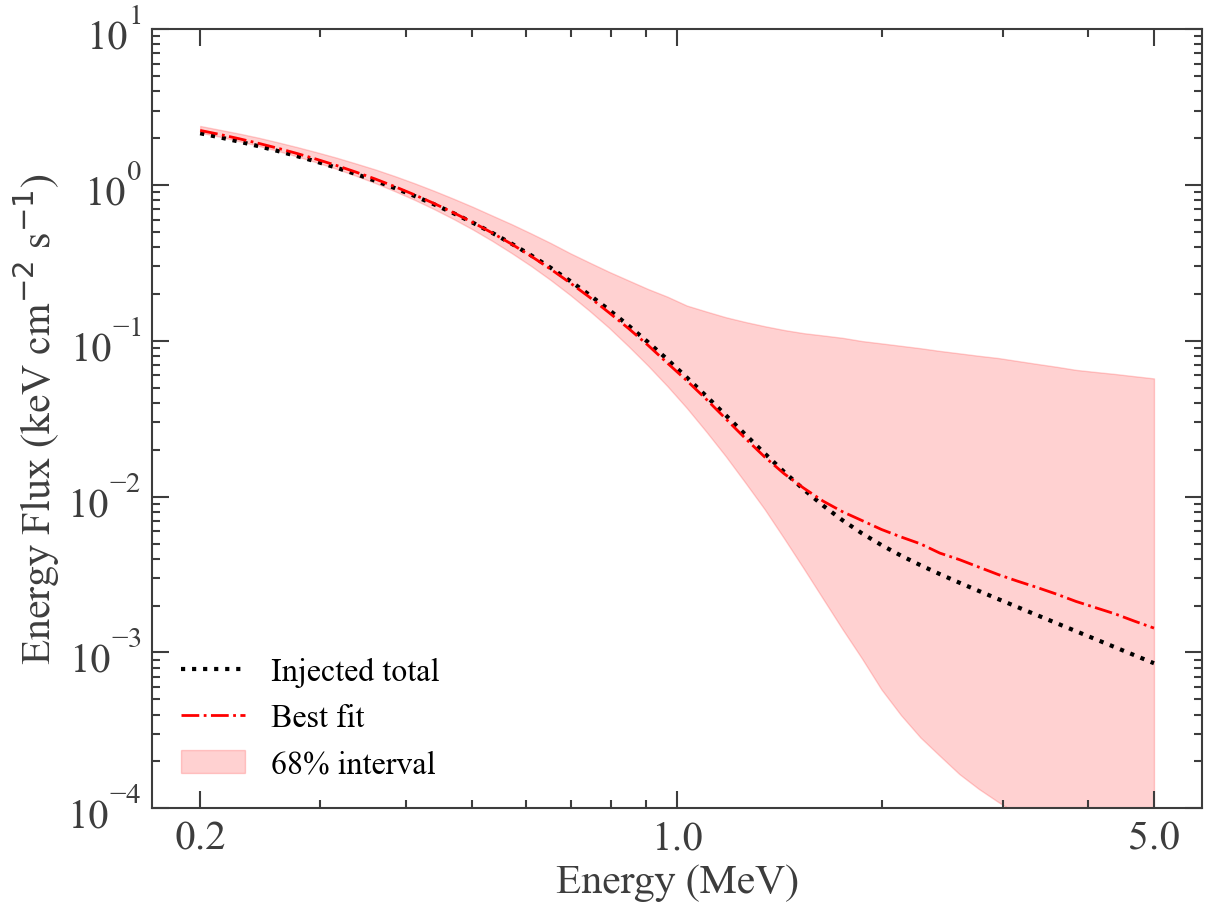

In [100]:
FONT_SIZE = 30
plt.rcParams["agg.path.chunksize"] = 10000
plt.rcParams.update({"font.size": FONT_SIZE})
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["axes.linewidth"] = 1.5
plt.rcParams.update({
    "font.weight": "550",
    "axes.titleweight": "550",
    "axes.labelweight": "550",
})


def style_axis(ax):
    ax.xaxis.set_tick_params(which="major", size=12, width=1.5, direction="in", top=True, pad=8, labelsize=FONT_SIZE)
    ax.xaxis.set_tick_params(which="minor", size=6, width=1.5, direction="in", top=True, pad=8)
    ax.yaxis.set_tick_params(which="major", size=12, width=1.5, direction="in", right=True, pad=8, labelsize=FONT_SIZE)
    ax.yaxis.set_tick_params(which="minor", size=6, width=1.5, direction="in", right=True, pad=8)
    ax.spines["right"].set_visible(True)
    ax.spines["top"].set_visible(True)


fig, ax = plt.subplots(figsize=(12, 9), constrained_layout=True)
style_axis(ax)

injected_label = "Injected total" if include_nonthermal_tail else "Injected thermal"
ax.plot(energy / 1000, energy * energy * flux_inj, color="black", ls=":", lw=3, label=injected_label)

ax.plot(
    energy / 1000,
    energy * energy * primary_fit["flux_median"],
    color=primary_fit["color"],
    lw=2,
    linestyle=primary_fit["linestyle"],
    label=f"Best fit",
)
ax.fill_between(
    energy / 1000,
    energy * energy * primary_fit["flux_lo"],
    energy * energy * primary_fit["flux_hi"],
    alpha=0.18,
    color=primary_fit["color"],
    label=f"68% interval",
)
ax.set_xscale("log")
ax.set_yscale("log")

ax.xaxis.set_major_locator(mticker.FixedLocator([0.2, 1.0, 5.0]))
ax.xaxis.set_major_formatter(mticker.FixedFormatter(["0.2", "1.0", "5.0"]))

ax.set_xlabel("Energy (MeV)", fontsize=FONT_SIZE)
ax.set_ylabel(r"Energy Flux (keV cm$^{-2}$ s$^{-1}$)", fontsize=FONT_SIZE)

ax.set_ylim(1e-4, 10)

_ = ax.legend(fontsize=23, loc="lower left", frameon=False)


Plot the fitted spectrum convolved with the response plus the fitted background, as well as the simulated source+background counts.


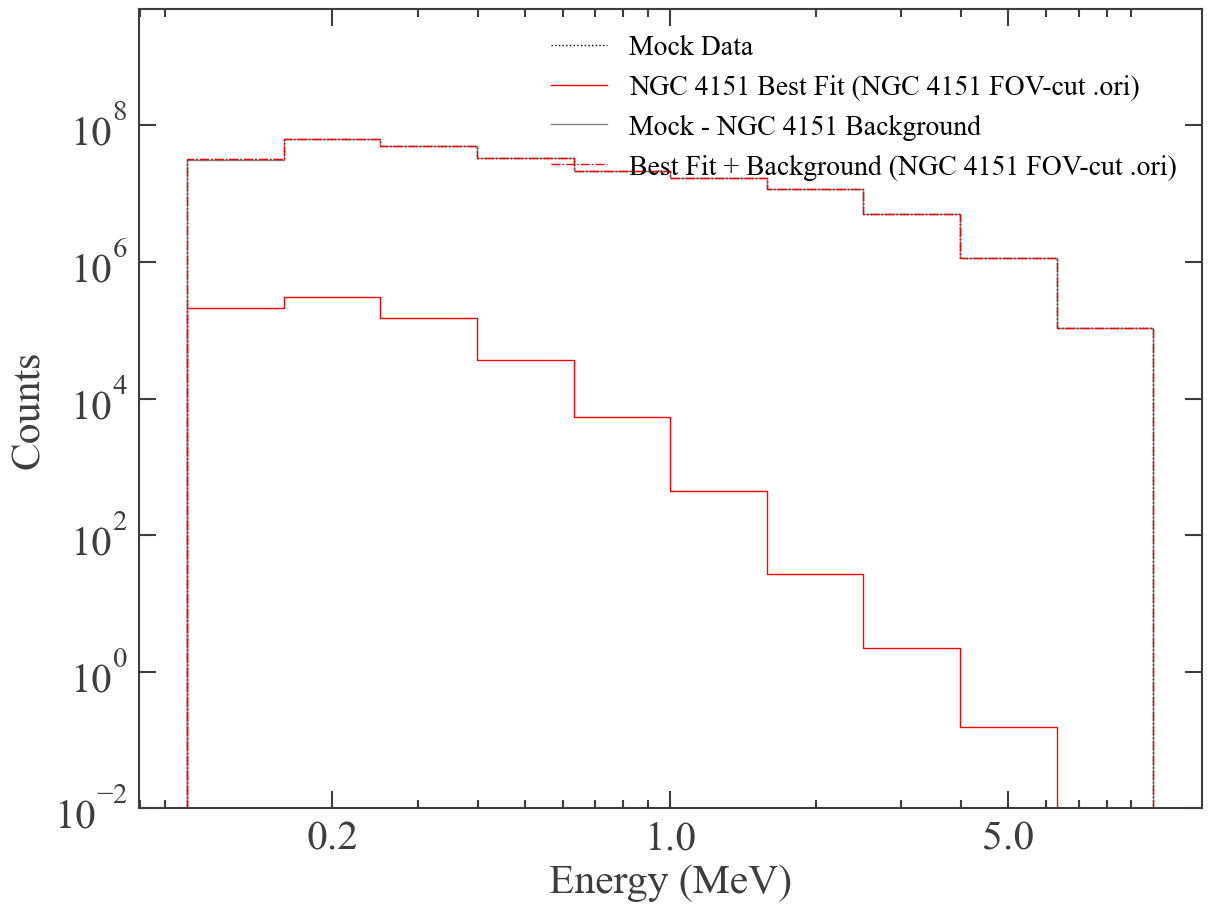

In [58]:
expectation_bkg = bkg.expectation(copy=True)

source_model_counts = expectation.project("Em").to_dense(copy=False).contents
background_counts = expectation_bkg.project("Em").to_dense(copy=False).contents
model_counts = source_model_counts + background_counts
data_counts = data.data.project("Em").to_dense(copy=False).contents

fig, ax = plt.subplots(figsize=(12, 9), constrained_layout=True)
style_axis(ax)

ax.stairs(data_counts, binned_energy_edges / 1000, label="Mock Data", color="black", linestyle=":")
ax.errorbar(binned_energy / 1000, data_counts, yerr=np.sqrt(data_counts), color="black", linewidth=0, elinewidth=1)
ax.stairs(source_model_counts, binned_energy_edges / 1000, label=f"NGC 4151 Best Fit ({primary_fit['label']})", color=primary_fit["color"])
ax.stairs(background_counts, binned_energy_edges / 1000, label="Mock - NGC 4151 Background", color="grey")
ax.stairs(model_counts, binned_energy_edges / 1000, label=f"Best Fit + Background ({primary_fit['label']})", color=primary_fit["color"], linestyle="dashdot")

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_ylabel("Counts", fontsize=FONT_SIZE)
ax.set_ylim(1e-2, 5e9)

ax.xaxis.set_major_locator(mticker.FixedLocator([0.2, 1.0, 5.0]))
ax.xaxis.set_major_formatter(mticker.FixedFormatter(["0.2", "1.0", "5.0"]))

ax.set_xlabel("Energy (MeV)", fontsize=FONT_SIZE)
ax.legend(fontsize=20, loc="upper right", frameon=False)

plt.show()
